In [254]:
# one of the package managers uv or pip or conda has f*cked up my PATH\n",
import sys
sys.path.append("/home/macbuse/miniconda3/lib/python3.11/site-packages")
 
import matplotlib.pyplot as plt
import numpy as np 

import re
import requests

import html #used for escaping entities

from collections import Counter #basic countings

---
# Dropdowns

U can get the department and the altitude from the dropdwn
at the top on the root **romma.fr**

In [135]:
user_agent = {'User-agent': 'Mozilla/5.0'}
r = requests.get('http://romma.fr', headers=user_agent)

In [219]:
pp = re.compile('<span>.+?(\d+\-.*?)</span>.*?<ul class="dropdown">\s+(.*?)</ul>', re.DOTALL)

text  = html.unescape(r.text) # swap out old style entities
mm = pp.findall(text)
dept, ll = list(zip(*mm))

In [274]:
p_station =  re.compile('id=(\d+).*?([A-Z].*?), (\d+)')

def do_stations(x):

    ids, names, alts = list(zip(*sp.findall(x)))
    ids = [int(_) for _ in ids]
    alts = [int(_) for _ in alts]
    return ids, names, alts

gps = [ do_stations(_) for _ in ll]

# look for depts with lots of stations
stuff = [(len(x[0]), i,dept[i]) for i,x in enumerate(gps)]
stuff.sort()

num, idx, name = list(zip(*stuff[-7:]))
did, name

((2, 1, 0, 5, 11, 10, 7),
 ('06-ALPES-MARITIMES',
  '04-ALPES DE HTE-PROVENCE',
  '01-AIN',
  '26-DRÔME',
  '74-HAUTE-SAVOIE',
  '73-SAVOIE',
  '38-ISÈRE'))

In [289]:
import pandas as pd

# Your original list comprehension
stuff = [(len(x[0]), dept[i]) for i, x in enumerate(gps)]

# Convert to DataFrame and label the columns
df = pd.DataFrame(stuff, columns=['Num_Stations',  'Department'])

# Sort by the busiest departments first to see your dense areas
df_sorted = df.sort_values(by='Num_Stations', ascending=False)

# Sort descending, grab the first 7, and extract their original index positions
top_7_indices = df_sorted.head(7).index

# If you need it as a standard Python list:
idxs = top_7_indices.tolist()

df_sorted

,Num_Stations,Department
7,65,38-ISÈRE
10,44,73-SAVOIE
11,40,74-HAUTE-SAVOIE
5,34,26-DRÔME
0,32,01-AIN
1,23,04-ALPES DE HTE-PROVENCE
2,15,06-ALPES-MARITIMES
13,14,84-VAUCLUSE
9,7,69-RHÔNE
6,4,30-GARD


In [294]:
with open('gps.txt','w') as fp:
    fp.write(str(gps))

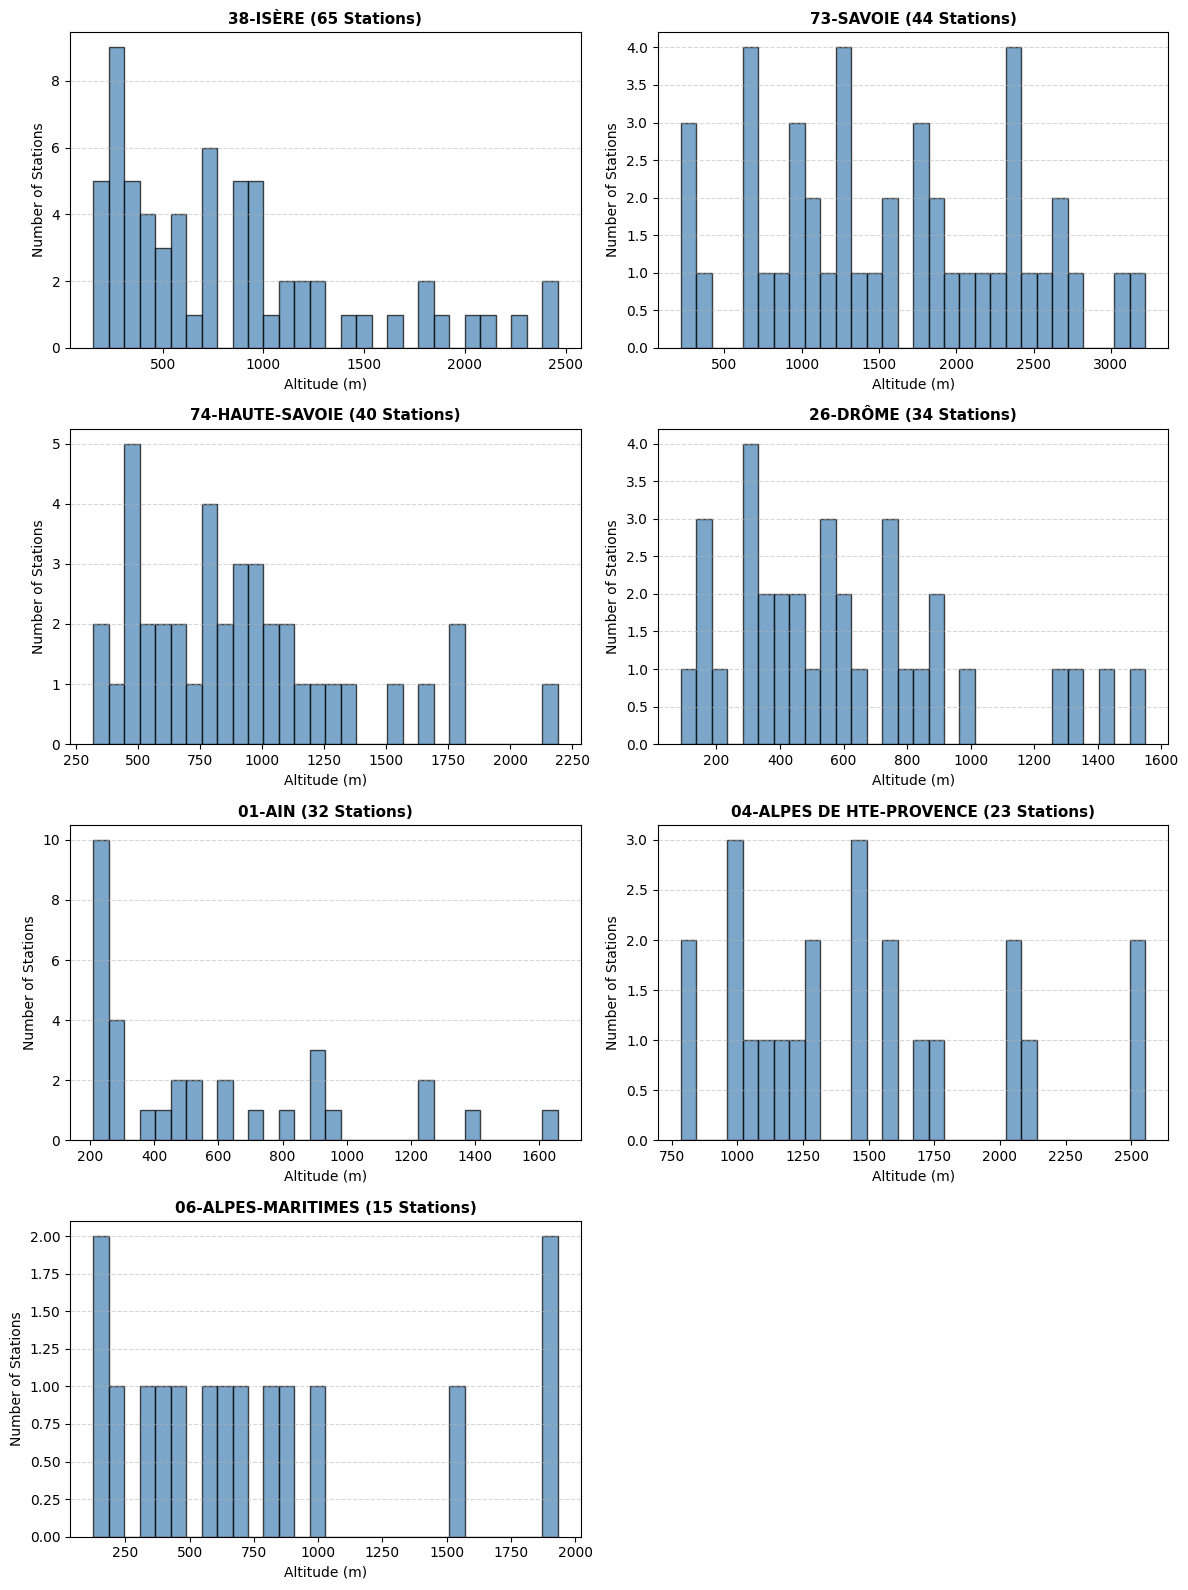

In [291]:
import math

# 1. Define the range of k indices you want to plot
# Update this list or use range(len(gps)) depending on your data structure
k_indices = idxs
num_plots = len(k_indices)

# 2. Determine grid dimensions dynamically (aiming for 2 columns max)
num_cols = 2 if num_plots > 1 else 1
num_rows = math.ceil(num_plots / num_cols)

# 3. Initialize the multiplot figure
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))

# Flatten axes array to make looping easy, even if it's a 1D grid or single plot
if num_plots > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# 4. Loop over indices and build each subplot
for idx, k in enumerate(k_indices):
    ax = axes[idx]
    
    # Extract data for the current region
    altitudes = gps[k][2]
    num_stations = len(altitudes)
    
    # Plot individual histogram
    ax.hist(altitudes, bins=30, 
            edgecolor='black', alpha=0.7, color='steelblue')
    
    # Polish individual labels and dynamic title
    ax.set_xlabel('Altitude (m)', fontsize=10)
    ax.set_ylabel('Number of Stations', fontsize=10)
    ax.set_title(f'{dept[k]} ({num_stations} Stations)', fontsize=11, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Hide any unused subplot tiles in the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and render
plt.tight_layout()
plt.show()


---
## check 

In [222]:
[ (x,y[1][0]) for x,y in zip(dept,gps)]

[('01-AIN', 'ST-VULBAS'),
 ('04-ALPES DE HTE-PROVENCE', 'GAP'),
 ('06-ALPES-MARITIMES', 'SOPHIA-ANTIPOLIS'),
 ('07-ARDÈCHE', 'TOURNON-SUR-RHÔNE'),
 ('13-BOUCHES-DU-RHONE', 'GRAVESON'),
 ('26-DRÔME', 'MONTELIMAR'),
 ('30-GARD', 'ST-PAUL-LES-FONTS'),
 ('38-ISÈRE', 'LE PEAGE-DE-ROUSSILLON'),
 ('39-JURA', 'MONTAGNA-LE-TEMPLIER'),
 ('69-RHÔNE', 'LYON'),
 ('73-SAVOIE', 'ST-GENIS-SUR-GUIERS'),
 ('74-HAUTE-SAVOIE', 'VALLIERES'),
 ('83-VAR', 'CHATEAUVIEUX'),
 ('84-VAUCLUSE', 'ORANGE')]

---

In [109]:
with open('romma_2026_05_25_09-04.html','r') as fp:
    text = fp.read()

In [3]:
text[:100]

'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-str'

In [33]:
p_row = re.compile(r'<tr>(.*?)</tr>', re.DOTALL)
p_tables = re.compile(r'<table class=.*?>(.*?)</table>(.*?)"', re.DOTALL)
data = p_tables.findall(text)
len(data)

631

In [117]:
data[0]

("<tr><td class=\\'none\\' width=\\'34%\\'>&nbsp;</td><td class=\\'blue\\' width=\\'22%\\'><strong>Actuel</strong></td><td class=\\'blue\\' width=\\'22%\\' >Max depuis 0h</td><td class=\\'blue\\' width=\\'22%\\' >Min depuis 0h</td></tr><tr><td class=\\'blue\\'>Temp&eacute;rature (°C)</td><td class=\\'blanc\\'><strong>18.4</strong></td><td class=\\'blanc\\'>18.8 &agrave; 08:23</td><td class=\\'blanc\\'>11.3 &agrave; 04:12</td></tr><tr><td class=\\'blue\\'>Humidit&eacute; (%)</td><td class=\\'blanc\\'><strong>51</strong></td><td class=\\'blanc\\'>64 &agrave; 02:06</td><td class=\\'blanc\\'>45 &agrave; 08:35</td></tr><tr><td class=\\'blue\\'>Vent et Dir (km/h)</td><td class=\\'blanc\\'><strong>5 </strong></td><td class=\\'blanc\\'>15 &agrave; 06:59</td><td class=\\'none\\'>&nbsp;</td></tr><tr><td class=\\'blue\\'>Rayonnement(w/m2)</td><td class=\\'blanc\\'><strong>522</strong></td><td class=\\'blanc\\'>522 &agrave; 08:52</td><td class=\\'none\\'>&nbsp;</td></tr><tr><td class=\\'blue\\'>Hu

In [103]:

tables, names = list(zip(*data))
all_names = ' '.join(names[::2])

p_name = re.compile(r".*?CAPTION,\s+\'(?P<station>.*?)\s\((?P<altitude>\d+)")
nn = p_name.findall(all_names)
nn[:10]

[('Orcières', '1620'),
 ('Les Molunes', '1250'),
 ("Saint-Martin-d\\'Hères", '218'),
 ('Vizille', '275'),
 ('Andilly - Mont-Sion', '800'),
 ('Le Sappey', '891'),
 ('Chamrousse', '1785'),
 ('Selonnet', '1061'),
 ('Col de Jaffueil', '2500'),
 ('Trept', '268')]

In [80]:
import html
import re

p_cell = re.compile('<td class=(.*?)</td>')


def get_station_type(x):
    try:
        rows = p_row.findall(x)
        station_data = [p_cell.findall(_) for _ in rows]

        # 1. Extract the raw matched strings
        raw_results = [ _[0] for _ in station_data[1:] if "blue" in _[0] ]

        # 2. Clean up any HTML entities converting them to proper UTF-8 strings
        clean_results = [html.unescape(item[len("\\'blue\\'>") :]) for item in raw_results]

        return clean_results
        
    except Exception:
        # Corrected capitalization for Python's None type
        return None

In [84]:
station_types = [get_station_type(_) for _ in tables[::2] ]

In [85]:
from collections import Counter

profile_distribution = Counter(
    len(_) for _ in station_type
)

In [86]:
profile_distribution

Counter({5: 98, 6: 75, 7: 54, 3: 45, 4: 35, 2: 7, 1: 2})

[('Orcières', '1620'),
 ('Les Molunes', '1250'),
 ("Saint-Martin-d\\'Hères", '218'),
 ('Vizille', '275'),
 ('Andilly - Mont-Sion', '800'),
 ('Le Sappey', '891'),
 ('Chamrousse', '1785'),
 ('Selonnet', '1061'),
 ('Col de Jaffueil', '2500'),
 ('Trept', '268')]